# Project 03 - Neural Networks & Backpropagation, FROM SCRATCH

**A self-explanatory Kaggle notebook.** We build a working neural network with nothing but
NumPy - writing the forward pass, the loss, and **backpropagation by hand** - and train it to
read handwritten digits (~97% accuracy). After this, deep learning stops being magic, because
you'll have built the engine yourself.

**What you'll learn**
- What a neuron, a layer, an activation, and a loss really are.
- **Backpropagation** explained as "the chain rule, layer by layer".
- **Gradient descent**: how a network actually *learns*.
- Why PyTorch's `loss.backward()` does exactly what you'll write by hand.

## The scenario
You're given thousands of tiny 8x8 grayscale images, each showing a handwritten digit 0-9. The
task: build something that looks at the 64 pixels and says which digit it is. This is the
"hello world" of deep learning, and the perfect size to build a network from scratch.

## Foundations (plain English)
- **Neuron** = takes inputs, multiplies each by a *weight*, adds them up (+ a *bias*), and passes
  the result through a *nonlinearity*. The weighted sum is just a matrix multiply `X @ W + b`.
- **Activation (ReLU)** = `max(0, x)`. Without a nonlinearity, stacking layers collapses into one
  plain linear layer - the nonlinearity is what gives a network its power.
- **Softmax** = turns the 10 output scores into 10 probabilities that add to 1.
- **Loss (cross-entropy)** = one number for "how wrong" the predictions are. Training = making it
  small.
- **Gradient** = the slope of the loss with respect to a weight: "nudge this weight up - does the
  loss rise or fall, and how fast?"
- **Backpropagation** = the chain rule, used to get every weight's gradient efficiently, from the
  output back to the input.
- **Gradient descent** = move each weight a small step *downhill*: `w -= learning_rate * gradient`.
  Repeat thousands of times and the loss falls.

### Cell 1 - imports and the dataset
`load_digits` is a tiny built-in dataset (no download). Each image is 8x8 = 64 numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
print("images:", digits.images.shape, "| labels:", digits.target.shape)

images: (1797, 8, 8) | labels: (1797,)


### Cell 2 - diagram: what do the digits look like?
Let's actually see a few. Each is a blurry 8x8 picture with its true label on top.

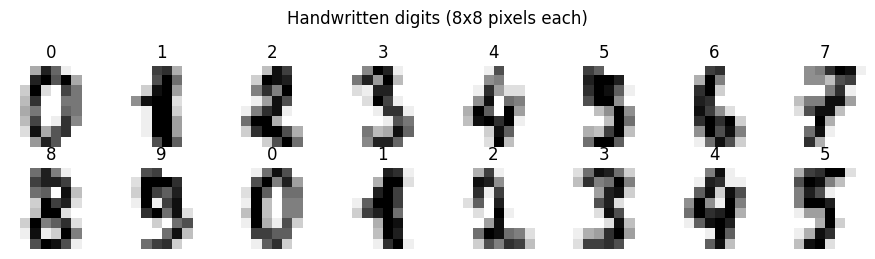

In [2]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(int(label)); ax.axis("off")
plt.suptitle("Handwritten digits (8x8 pixels each)"); plt.tight_layout(); plt.show()

### Cell 3 - prepare the data
We flatten each 8x8 image into 64 numbers, scale pixels to [0,1] (networks like small inputs),
turn labels into **one-hot** vectors (a 7 becomes [0,0,0,0,0,0,0,1,0,0]), and split train/test.

In [3]:
X = digits.data / 16.0
y = digits.target
def one_hot(y, k=10):
    o = np.zeros((y.size, k)); o[np.arange(y.size), y] = 1.0; return o
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
Ytr = one_hot(ytr)
print("train:", Xtr.shape, "| test:", Xte.shape)

train: (1437, 64) | test: (360, 64)


### Cell 4 - the math building blocks
`relu` keeps positives, zeros negatives. `softmax` makes probabilities (we subtract the row max
first so big numbers don't overflow). `cross_entropy` is the average negative log-probability of
the correct class.

In [4]:
def relu(z): return np.maximum(0.0, z)
def softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z); return e / e.sum(axis=1, keepdims=True)
def cross_entropy(P, Y): return -np.mean(np.sum(Y*np.log(P+1e-12), axis=1))
print("math helpers ready")

math helpers ready


### Cell 5 - the network: forward AND backward by hand
Architecture: `64 -> Linear -> ReLU -> Linear -> Softmax`. Read `forward` (predictions) and then
`backward` (the chain rule). The star line is `dZ2 = (P - Y)/n` - for softmax+cross-entropy the
output gradient is simply "prediction minus truth", which is *why* those two are always paired.
Everything after it is the chain rule walking the error back through the layers.

In [5]:
class MLP:
    def __init__(self, d_in, d_hidden, d_out, seed=0):
        rng = np.random.default_rng(seed)
        # He initialization (variance 2/fan_in) keeps signals stable through ReLU
        self.W1 = rng.standard_normal((d_in, d_hidden))*np.sqrt(2/d_in); self.b1 = np.zeros(d_hidden)
        self.W2 = rng.standard_normal((d_hidden, d_out))*np.sqrt(2/d_hidden); self.b2 = np.zeros(d_out)
    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1      # hidden pre-activation (weighted sum)
        self.A1 = relu(self.Z1)              # hidden activation
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.P  = softmax(self.Z2)           # class probabilities
        return self.P
    def backward(self, Y):
        n = Y.shape[0]
        dZ2 = (self.P - Y)/n                  # gradient of softmax+cross-entropy: prediction - truth
        dW2 = self.A1.T @ dZ2; db2 = dZ2.sum(0)
        dA1 = dZ2 @ self.W2.T                 # push error back to hidden layer
        dZ1 = dA1 * (self.Z1 > 0)            # ReLU derivative: 1 where input was positive
        dW1 = self.X.T @ dZ1; db1 = dZ1.sum(0)
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
    def step(self, g, lr):
        self.W1 -= lr*g["W1"]; self.b1 -= lr*g["b1"]; self.W2 -= lr*g["W2"]; self.b2 -= lr*g["b2"]
    def predict(self, X): return self.forward(X).argmax(1)
print("MLP defined")

MLP defined


### Cell 6 - train it (mini-batch gradient descent)
One **epoch** = one pass over all training data, done in small **batches** of 64. For each batch
we: forward (predict) -> backward (gradients) -> step (update weights). We record the loss each
epoch so we can plot learning.

In [6]:
net = MLP(64, 64, 10)
lr, epochs, batch = 0.5, 60, 64
rng = np.random.default_rng(0)
losses, accs = [], []
for ep in range(epochs):
    order = rng.permutation(len(Xtr))
    for s in range(0, len(Xtr), batch):
        b = order[s:s+batch]
        net.forward(Xtr[b]); net.step(net.backward(Ytr[b]), lr)
    losses.append(cross_entropy(net.forward(Xtr), Ytr))
    accs.append((net.predict(Xte) == yte).mean())
print(f"FINAL test accuracy: {accs[-1]:.3f}")

FINAL test accuracy: 0.975


### Cell 7 - diagram: the learning curve
As training proceeds, the loss should fall and accuracy should rise. *Seeing* the loss go down
is *seeing* the network learn.

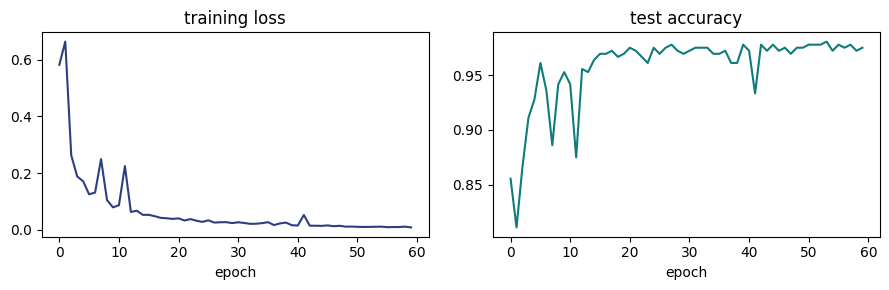

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(losses, color="#2d3e80"); ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(accs, color="#0e7c7b"); ax[1].set_title("test accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

### Cell 8 - diagram: predictions on real test digits
Green title = correct, red = wrong. With ~97% accuracy, almost all should be green.

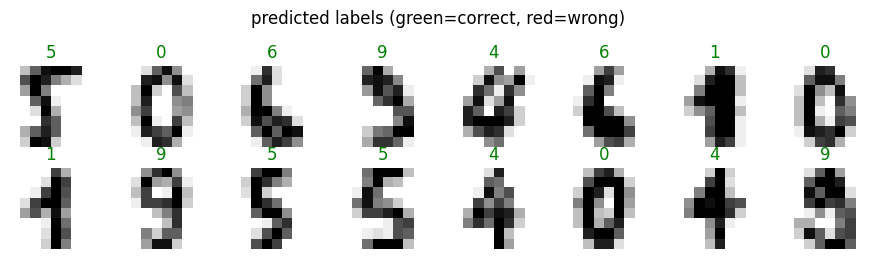

In [8]:
idx = rng.choice(len(Xte), 16, replace=False)
preds = net.predict(Xte[idx])
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, i, p in zip(axes.ravel(), idx, preds):
    ax.imshow(Xte[i].reshape(8,8), cmap="gray_r")
    ax.set_title(int(p), color=("green" if p == yte[i] else "red")); ax.axis("off")
plt.suptitle("predicted labels (green=correct, red=wrong)"); plt.tight_layout(); plt.show()

### Cell 9 - PROOF the backprop is correct (gradient check)
Backprop is easy to get subtly wrong. We compare each analytic gradient to a **numerical** one,
`(loss(w+eps) - loss(w-eps)) / (2*eps)`. If they agree to ~1e-6, the math is right. This is how
engineers debug custom layers in the real world.

In [9]:
rng2 = np.random.default_rng(1)
Xc = rng2.standard_normal((8, 64)); Yc = one_hot(rng2.integers(0,10,8))
chk = MLP(64, 16, 10, seed=2); chk.forward(Xc); g = chk.backward(Yc)
eps, worst = 1e-5, 0.0
for name in ["W1","b1","W2","b2"]:
    flat = getattr(chk, name).ravel(); gg = g[name].ravel()
    for i in rng2.choice(flat.size, size=min(20, flat.size), replace=False):
        o = flat[i]
        flat[i] = o+eps; lp = cross_entropy(chk.forward(Xc), Yc)
        flat[i] = o-eps; lm = cross_entropy(chk.forward(Xc), Yc)
        flat[i] = o
        worst = max(worst, abs((lp-lm)/(2*eps) - gg[i]) / max(1e-8, abs((lp-lm)/(2*eps))+abs(gg[i])))
print(f"worst relative error: {worst:.2e}  ->", "PASS (backprop is correct)" if worst < 1e-4 else "FAIL")

worst relative error: 2.51e-09  -> PASS (backprop is correct)


### The same thing in PyTorch (for later)
Every real project uses a framework. In PyTorch you write only the forward pass; `loss.backward()`
computes all those gradients automatically (it's doing exactly your `backward()` above):

```python
import torch, torch.nn as nn
net = nn.Sequential(nn.Linear(64,64), nn.ReLU(), nn.Linear(64,10))
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()           # softmax + cross-entropy in one
# training step:
opt.zero_grad(); logits = net(X); loss = loss_fn(logits, y); loss.backward(); opt.step()
```
You understand what `loss.backward()` does because you just wrote it by hand.

## What just happened (recap)
1. We turned images into numbers and one-hot labels.
2. We built a 2-layer network: **forward** (predict) and **backward** (chain-rule gradients).
3. We trained with **mini-batch gradient descent** and watched the loss fall to ~97% accuracy.
4. We **proved** our backprop is correct with a gradient check.
5. We saw that PyTorch's `loss.backward()` automates exactly this.

## Scenarios & your turn
- **Learning rate:** change `lr` to 5.0 (watch it diverge) and to 0.01 (watch it crawl).
- **Capacity:** make the hidden layer 16 vs 256 - more isn't always better.
- **Add a layer:** insert a second hidden layer and re-derive the two extra backward lines.
- **Scale up:** the same ideas, with convolutions, become the image models in Project 04.

## Mini-glossary
**neuron / weight / bias** the basic unit - **activation (ReLU)** the nonlinearity - **softmax**
scores -> probabilities - **loss / cross-entropy** how wrong - **forward pass** predict -
**backpropagation** chain-rule gradients - **gradient descent / learning rate** how it learns -
**epoch / batch** one data pass / a small chunk - **autograd** PyTorch automating backward().